# Notebook 02 — Clinical Cohort Construction, Target Definition & Intelligent Feature Engineering

## Trustworthy Agentic AI for Healthcare

### Objective

This notebook transforms the integrated healthcare dataset generated by Notebook 01
into a reproducible, leakage-aware modelling cohort for diabetes prediction.

The notebook performs:

1. Dataset validation
2. Clinical schema discovery
3. Participant-level cohort construction
4. Target-variable identification and definition
5. Target-leakage screening
6. Special-code and missing-data analysis
7. High-missingness feature filtering
8. Clinically motivated feature engineering
9. Participant-level train/test splitting
10. Predictive feature governance
11. Leakage-safe preprocessing
12. Feature quality auditing
13. Reproducible dataset versioning
14. Export of modelling-ready data and metadata

### Primary modelling target

`diabetes_target`

where:

- `1` = physician/health-professional diagnosed diabetes (`DIQ010 = 1`)
- `0` = no physician/health-professional diagnosed diabetes (`DIQ010 = 2`)

Borderline/prediabetes (`DIQ010 = 3`), refused (`7`), don't know (`9`),
and missing responses are excluded from the primary binary classification cohort.

### Leakage-control principles

- The original target variable is never used as a predictor.
- Other diabetes questionnaire (`DIQ*`) variables are excluded.
- Participant IDs are never used as predictive features.
- NHANES survey-design and sampling-weight variables are excluded from
  predictive modelling.
- Train/test separation is performed at the participant level.
- Imputation, scaling, and categorical encoding are fitted using training data only.
- No predictive model is trained in this notebook.

The final outputs of this notebook form the controlled input for Notebook 03,
where predictive models will be trained and evaluated.

In [1]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import os
import re
import json
import hashlib
import warnings

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# CELL 3 — PROJECT DIRECTORIES
# ============================================================

PROJECT_ROOT = Path(
    "/content/trustworthy_agentic_ai_healthcare"
)

DIRS = {
    "root": PROJECT_ROOT,
    "outputs": PROJECT_ROOT / "outputs",
    "reports": PROJECT_ROOT / "reports",
    "figures": PROJECT_ROOT / "figures",
    "metadata": PROJECT_ROOT / "metadata",
    "data": PROJECT_ROOT / "data",
}

for directory in DIRS.values():
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project directories created:")

for name, directory in DIRS.items():
    print(f"{name:12s} -> {directory}")

Project directories created:
root         -> /content/trustworthy_agentic_ai_healthcare
outputs      -> /content/trustworthy_agentic_ai_healthcare/outputs
reports      -> /content/trustworthy_agentic_ai_healthcare/reports
figures      -> /content/trustworthy_agentic_ai_healthcare/figures
metadata     -> /content/trustworthy_agentic_ai_healthcare/metadata
data         -> /content/trustworthy_agentic_ai_healthcare/data


In [3]:
# ============================================================
# CELL 4 — UPLOAD MASTER DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")

for filename in uploaded.keys():
    print(" -", filename)

Saving master_healthcare_dataset.csv to master_healthcare_dataset.csv

Uploaded files:
 - master_healthcare_dataset.csv


In [4]:
# ============================================================
# CELL 5 — LOCATE MASTER DATASET
# ============================================================

EXPECTED_FILENAME = "master_healthcare_dataset.csv"

expected_path = Path("/content") / EXPECTED_FILENAME

if expected_path.exists():

    MASTER_DATA_PATH = expected_path

else:

    csv_candidates = list(
        Path("/content").glob("*.csv")
    )

    if len(csv_candidates) == 1:

        MASTER_DATA_PATH = csv_candidates[0]

    elif len(csv_candidates) > 1:

        print("Multiple CSV files found:")

        for i, file in enumerate(csv_candidates):
            print(f"{i}: {file.name}")

        raise FileNotFoundError(
            "Please upload master_healthcare_dataset.csv."
        )

    else:

        raise FileNotFoundError(
            "master_healthcare_dataset.csv was not found."
        )

print("Master dataset:")
print(MASTER_DATA_PATH)

Master dataset:
/content/master_healthcare_dataset.csv


In [5]:
# ============================================================
# CELL 6 — LOAD MASTER DATASET
# ============================================================

df = pd.read_csv(
    MASTER_DATA_PATH
)

print("Dataset loaded successfully.")

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")

display(df.head())

Dataset loaded successfully.
Rows    : 32,962
Columns : 301


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDYRUSZ,DMDEDUC2,DMDMARTZ,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINTPRP,WTMECPRP,SDMVPSU,SDMVSTRA,INDFMPIR,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMDBMIC,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP,BPAOARM,BPAOCSZ,BPXOSY1,BPXODI1,BPXOSY2,BPXODI2,BPXOSY3,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,WTSAFPRP_x,LBXGLU,LBDGLUSI,LBXGH,LBXTC,LBDTCSI,WTSAFPRP_y,LBXTR,LBDTRSI,LBDLDL,LBDLDLSI,LBDLDLM,LBDLDMSI,LBDLDLN,LBDLDNSI,LBDHDD,LBDHDDSI,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT,LBDLYMNO,LBDMONO,LBDNENO,LBDEONO,LBDBANO,LBXRBCSI,LBXHGB,LBXHCT,LBXMCVSI,LBXMC,LBXMCHSI,LBXRDW,LBXPLTSI,LBXMPSI,LBXNRBC,LBXSATSI,...,DBQ360,DBQ370,DBD381,DBQ390,DBQ400,DBD411,DBQ421,DBQ424,DBD895,DBD900,DBD905,DBD910,CBQ596,CBQ606,CBQ611,DBQ930,DBQ935,DBQ940,DBQ945,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680,SLQ300,SLQ310,SLD012,SLQ320,SLQ330,SLD013,SLQ030,SLQ040,SLQ050,SLQ120,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ290,ALQ151,ALQ170,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD057,SMQ078,SMD641,SMD650,SMD100FL,SMD100MN,SMQ670,SMQ621,SMD630,SMAQUEX2,HIQ011,HIQ032A,HIQ032B,HIQ032C,HIQ032D,HIQ032E,HIQ032H,HIQ032I,HIQ032J,HIQ260,HIQ105,HIQ270,HIQ210,HUQ010,HUQ030,HUQ051,HUD062,HUQ071,HUQ090,RXDUSE,RXDDRUG,RXDDRGID,RXQSEEN,RXDDAYS,RXDRSC1,RXDRSC2,RXDRSC3,RXDRSD1,RXDRSD2,RXDRSD3,RXDCOUNT
0,109263.0,66.0,2.0,1.0,2.0,NaN,5.0,6.0,2.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,7891.762435,8.951816e+03,3.0,156.0,4.66,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,5.397605e-79,5.397605e-79,5.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2.0,1.0,1.0,1.000000e+00,NaN,2.0,NaN,2.0,b'',b'',NaN,NaN,b'',b'',b'',b'',b'',b'',NaN
1,109264.0,66.0,2.0,2.0,13.0,NaN,1.0,1.0,2.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,11689.747264,1.227116e+04,1.0,155.0,0.83,1.0,42.2,NaN,NaN,NaN,NaN,NaN,154.7,NaN,17.6,2.0,36.3,NaN,33.8,NaN,22.7,NaN,63.8,NaN,85.0,NaN,b'R',3.0,109.0,67.0,109.0,68.0,106.0,66.0,94.0,95.0,91.0,27533.174559,97.0,5.38,5.3,166.0,4.29,27533.174559,40.0,0.452,86.0,2.224,82.0,2.121,85.0,2.198,72.0,1.86,4.5,45.6,6.2,46.4,1.4,0.5,2.1,0.3,2.1,0.1,5.397605e-79,4.80,13.7,40.5,84.3,33.7,28.4,13.1,263.0,8.2,0.1,8.0,...,1.0,1.0,5.0,1.0,1.0,1.0,1.0,2.0,1.0,5.397605e-79,1.000000e+00,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN,1.0,2.0,2.0,1.0,5.397605e-79,2.0,2.0,1.0,2.0,b'',b'',NaN,NaN,b'',b'',b'',b'',b'',b'',NaN
2,109265.0,66.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,NaN,16273.825939,1.665876e+04,1.0,157.0,3.06,1.0,12.0,NaN,91.6,NaN,NaN,NaN,89.3,NaN,15.0,2.0,NaN,NaN,18.6,NaN,14.8,NaN,41.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.5,46.4,10.9,39.2,2.9,0.7,4.4,1.0,3.7,0.3,1.000000e-01,4.50,12.6,36.6,81.2,34.4,27.9,13.1,286.0,6.6,0.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.000000e+00,5.397605e-79,2.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [6]:
# ============================================================
# CELL 7 — DATASET FINGERPRINT
# ============================================================

with open(MASTER_DATA_PATH, "rb") as f:
    dataset_hash = hashlib.sha256(
        f.read()
    ).hexdigest()

dataset_metadata = {
    "filename": MASTER_DATA_PATH.name,
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "sha256": dataset_hash,
    "created_at": datetime.now().isoformat(),
}

print(
    json.dumps(
        dataset_metadata,
        indent=4
    )
)

with open(
    DIRS["metadata"] / "dataset_fingerprint.json",
    "w"
) as f:

    json.dump(
        dataset_metadata,
        f,
        indent=4
    )

print("\nDataset fingerprint saved.")

{
    "filename": "master_healthcare_dataset.csv",
    "rows": 32962,
    "columns": 301,
    "sha256": "35ef4f19f95b5100def817cfdb1fcdec621a9af5f87e66ca0e94ddc4b0d474eb",
    "created_at": "2026-08-20T18:30:09.301235"
}

Dataset fingerprint saved.


In [7]:
# ============================================================
# CELL 8 — STRUCTURAL AUDIT
# ============================================================

print("=" * 70)
print("DATASET STRUCTURAL AUDIT")
print("=" * 70)

print(
    f"Number of observations : {df.shape[0]:,}"
)

print(
    f"Number of variables    : {df.shape[1]:,}"
)

print(
    f"Memory usage           : "
    f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")

display(
    df.dtypes
      .value_counts()
      .rename_axis("dtype")
      .reset_index(name="count")
)

DATASET STRUCTURAL AUDIT
Number of observations : 32,962
Number of variables    : 301
Memory usage           : 94.84 MB

Duplicate rows:
34

Data types:


,dtype,count
0,float64,288
1,object,13


In [8]:
# ============================================================
# CELL 9 — COLUMN INVENTORY
# ============================================================

column_inventory = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_percent": (
        df.isna().mean() * 100
    ).values,
    "unique_values": (
        df.nunique(dropna=True)
    ).values,
})

column_inventory["is_constant"] = (
    column_inventory["unique_values"] <= 1
)

column_inventory = column_inventory.sort_values(
    by="missing_percent",
    ascending=False
)

display(
    column_inventory.head(50)
)

column_inventory.to_csv(
    DIRS["metadata"] / "column_inventory.csv",
    index=False
)

print("Column inventory saved.")

,column,dtype,missing_count,missing_percent,unique_values,is_constant
35,BMIHEAD,float64,32962,100.000000,0,True
278,HIQ032J,float64,32960,99.993932,1,True
184,DBQ073D,float64,32945,99.948425,1,True
33,BMIRECUM,float64,32912,99.848310,1,True
185,DBQ073E,float64,32905,99.827074,1,True
183,DBQ073C,float64,32859,99.687519,1,True
268,SMD630,float64,32856,99.678418,10,False
186,DBQ073U,float64,32814,99.550998,1,True
275,HIQ032E,float64,32757,99.378072,1,True
34,BMXHEAD,float64,32642,99.029185,101,False


Column inventory saved.


In [9]:
# ============================================================
# CELL 10 — IDENTIFIER DISCOVERY
# ============================================================

identifier_candidates = [
    col
    for col in df.columns
    if any(
        keyword in col.upper()
        for keyword in [
            "SEQN",
            "ID",
            "IDENTIFIER",
            "PATIENT"
        ]
    )
]

print("Potential identifier columns:")

for col in identifier_candidates:
    print(" -", col)

if "SEQN" in df.columns:

    ID_COLUMN = "SEQN"

else:

    ID_COLUMN = None

    print(
        "\nSEQN was not automatically detected."
    )

Potential identifier columns:
 - SEQN
 - RIDSTATR
 - RIDAGEYR
 - RIDAGEMN
 - RIDRETH1
 - RIDRETH3
 - RIDEXMON
 - RIDEXPRG
 - DID040
 - DID060
 - DID250
 - DID260
 - DID310S
 - DID310D
 - DID320
 - DID330
 - DID341
 - DID350
 - RXDDRGID


In [10]:
# ============================================================
# CELL 11 — IDENTIFIER QUALITY CHECK
# ============================================================

if ID_COLUMN is not None:

    print(
        f"Identifier selected: {ID_COLUMN}"
    )

    print("\nMissing identifiers:")
    print(
        df[ID_COLUMN].isna().sum()
    )

    print("\nDuplicate identifiers:")
    print(
        df[ID_COLUMN].duplicated().sum()
    )

    print("\nUnique identifiers:")
    print(
        df[ID_COLUMN].nunique()
    )

    print("\nExample identifiers:")

    display(
        df[[ID_COLUMN]].head(10)
    )

else:

    raise ValueError(
        "SEQN is required for participant-level leakage-safe splitting."
    )

Identifier selected: SEQN

Missing identifiers:
0

Duplicate identifiers:
17402

Unique identifiers:
15560

Example identifiers:


,SEQN
0,109263.0
1,109264.0
2,109265.0
3,109266.0
4,109267.0
5,109268.0
6,109269.0
7,109269.0
8,109270.0
9,109271.0


In [11]:
# ============================================================
# CELL 12 — CLINICAL VARIABLE DISCOVERY
# ============================================================

clinical_keywords = [
    "DIAB",
    "GLUCOSE",
    "A1C",
    "HBA1C",
    "CKD",
    "KIDNEY",
    "CREAT",
    "ALBUMIN",
    "URINE",
    "BLOOD",
    "PRESSURE",
    "HYPERT",
    "CHOLESTEROL",
    "HDL",
    "LDL",
    "TRIG",
    "BMI",
    "WEIGHT",
    "HEIGHT",
    "SMOKE",
    "ALCOHOL",
    "AGE",
    "SEX",
    "RACE",
    "EDUC",
    "INCOME",
]

clinical_candidates = []

for col in df.columns:

    col_upper = col.upper()

    if any(
        keyword in col_upper
        for keyword in clinical_keywords
    ):

        clinical_candidates.append(col)

print(
    f"Potential clinical/demographic variables: "
    f"{len(clinical_candidates)}"
)

for col in clinical_candidates:
    print(col)

Potential clinical/demographic variables: 19
RIAGENDR
RIDAGEYR
RIDAGEMN
DMDEDUC2
BMIWT
BMIRECUM
BMIHEAD
BMIHT
BMXBMI
BMDBMIC
BMILEG
BMIARML
BMIARMC
BMIWAIST
BMIHIP
LBDLDL
LBDLDLSI
LBDLDLM
LBDLDLN


In [12]:
# ============================================================
# CELL 13 — CLINICAL VARIABLE INVENTORY
# ============================================================

clinical_inventory = pd.DataFrame({
    "column": clinical_candidates
})

clinical_inventory["dtype"] = (
    clinical_inventory["column"]
    .map(df.dtypes.astype(str))
)

clinical_inventory["missing_percent"] = (
    clinical_inventory["column"]
    .map(df.isna().mean() * 100)
)

clinical_inventory["unique_values"] = (
    clinical_inventory["column"]
    .map(df.nunique(dropna=True))
)

display(clinical_inventory)

clinical_inventory.to_csv(
    DIRS["metadata"] /
    "clinical_variable_inventory.csv",
    index=False
)

,column,dtype,missing_percent,unique_values
0,RIAGENDR,float64,0.000000,2
1,RIDAGEYR,float64,0.000000,81
2,RIDAGEMN,float64,96.793277,25
3,DMDEDUC2,float64,21.891875,7
4,BMIWT,float64,95.573691,3
5,BMIRECUM,float64,99.848310,1
6,BMIHEAD,float64,100.000000,0
7,BMIHT,float64,97.809599,2
8,BMXBMI,float64,13.178812,478
9,BMDBMIC,float64,83.301984,4


In [13]:
# ============================================================
# CELL 14 — MISSINGNESS ANALYSIS
# ============================================================

missingness = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("missing_percent")
)

missingness["missing_count"] = (
    df.isna().sum()
)

display(
    missingness.head(50)
)

,missing_percent,missing_count
BMIHEAD,100.000000,32962
HIQ032J,99.993932,32960
DBQ073D,99.948425,32945
BMIRECUM,99.848310,32912
DBQ073E,99.827074,32905
DBQ073C,99.687519,32859
SMD630,99.678418,32856
DBQ073U,99.550998,32814
HIQ032E,99.378072,32757
BMXHEAD,99.029185,32642


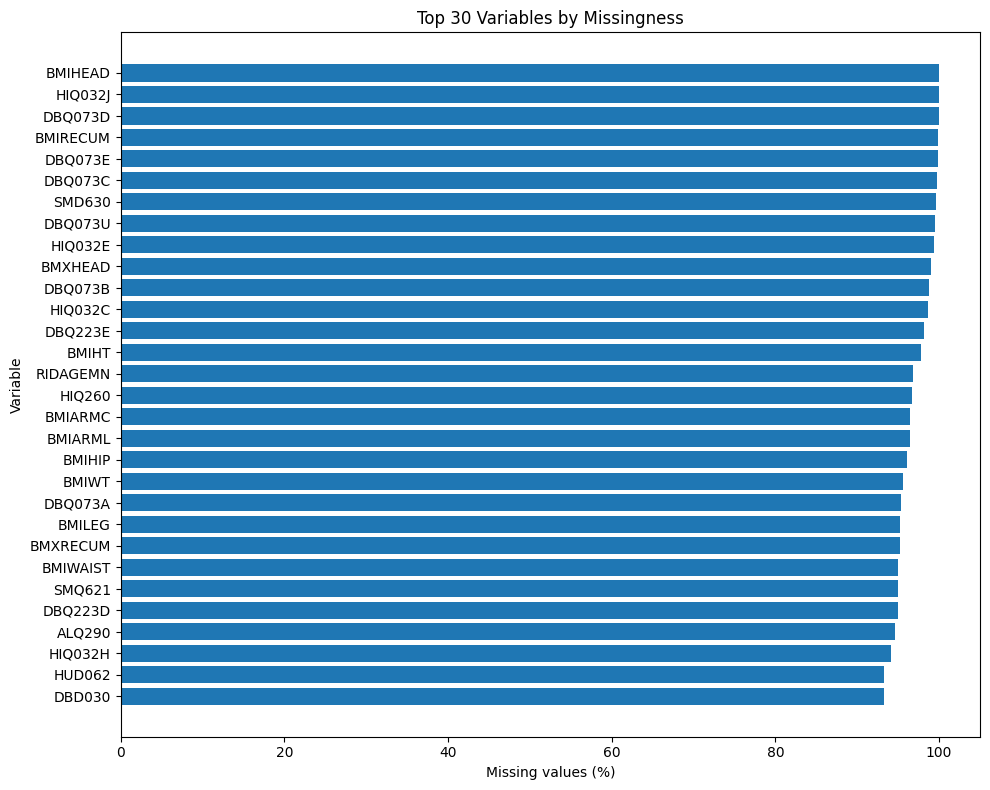

Figure saved to: /content/trustworthy_agentic_ai_healthcare/figures/missingness_top30.png


In [14]:
# ============================================================
# CELL 15 — MISSINGNESS VISUALIZATION
# ============================================================

top_missing = (
    missingness
    .head(30)
    .sort_values("missing_percent")
)

plt.figure(
    figsize=(10, 8)
)

plt.barh(
    top_missing.index,
    top_missing["missing_percent"]
)

plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.title("Top 30 Variables by Missingness")

plt.tight_layout()

missing_plot_path = (
    DIRS["figures"] /
    "missingness_top30.png"
)

plt.savefig(
    missing_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved to: {missing_plot_path}"
)

In [15]:
# ============================================================
# CELL 16 — CONSTANT AND LOW-VARIABILITY FEATURES
# ============================================================

constant_columns = [
    col
    for col in df.columns
    if df[col].nunique(dropna=True) <= 1
]

print(
    f"Constant variables: "
    f"{len(constant_columns)}"
)

for col in constant_columns:
    print(" -", col)

low_cardinality = (
    df.nunique(dropna=True)
      .sort_values()
      .to_frame("unique_values")
)

display(
    low_cardinality.head(40)
)

Constant variables: 25
 - SDDSRVYR
 - BMIRECUM
 - BMIHEAD
 - BMILEG
 - BMIARML
 - BMIARMC
 - BMIWAIST
 - BMIHIP
 - DBQ073B
 - DBQ073C
 - DBQ073D
 - DBQ073E
 - DBQ073U
 - DBQ223B
 - DBQ223C
 - DBQ223D
 - DBQ223E
 - DBQ223U
 - HIQ032B
 - HIQ032C
 - HIQ032D
 - HIQ032E
 - HIQ032H
 - HIQ032I
 - HIQ032J


,unique_values
BMIHEAD,0
SDDSRVYR,1
BMIRECUM,1
HIQ032B,1
BMILEG,1
HIQ032C,1
HIQ032D,1
HIQ032E,1
BMIHIP,1
BMIWAIST,1


In [16]:
# ============================================================
# CELL 17 — NUMERIC FEATURE SUMMARY
# ============================================================

numeric_columns = (
    df.select_dtypes(
        include=np.number
    ).columns.tolist()
)

numeric_summary = (
    df[numeric_columns]
    .describe()
    .T
)

numeric_summary["missing_percent"] = (
    df[numeric_columns]
    .isna()
    .mean() * 100
)

numeric_summary["unique_values"] = (
    df[numeric_columns]
    .nunique()
)

display(numeric_summary)

numeric_summary.to_csv(
    DIRS["metadata"] /
    "numeric_feature_summary.csv"
)

,count,mean,std,min,25%,50%,75%,max,missing_percent,unique_values
SEQN,32962.0,117047.003368,4489.492652,1.092630e+05,113128.0,117020.5,120928.75,124822.0,0.000000,15560
SDDSRVYR,32962.0,66.000000,0.000000,6.600000e+01,66.0,66.0,66.00,66.0,0.000000,1
RIDSTATR,32962.0,1.923761,0.265385,1.000000e+00,2.0,2.0,2.00,2.0,0.000000,2
RIAGENDR,32962.0,1.518263,0.499674,1.000000e+00,1.0,2.0,2.00,2.0,0.000000,2
RIDAGEYR,32962.0,48.270129,25.575401,5.397605e-79,26.0,56.0,69.00,80.0,0.000000,81
...,...,...,...,...,...,...,...,...,...,...
HUQ090,31113.0,1.847749,0.387256,1.000000e+00,2.0,2.0,2.00,9.0,5.609490,4
RXDUSE,32962.0,1.267186,0.464507,1.000000e+00,1.0,1.0,2.00,9.0,0.000000,4
RXQSEEN,24037.0,1.167741,0.483617,1.000000e+00,1.0,1.0,1.00,3.0,27.076634,3
RXDDAYS,24031.0,4175.267363,14172.013879,1.000000e+00,365.0,1095.0,3650.00,99999.0,27.094836,161


In [17]:
# ============================================================
# CELL 18 — CATEGORICAL FEATURE SUMMARY
# ============================================================

categorical_columns = (
    df.select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    ).columns.tolist()
)

categorical_summary = pd.DataFrame({
    "column": categorical_columns,
    "unique_values": [
        df[col].nunique(dropna=True)
        for col in categorical_columns
    ],
    "missing_percent": [
        df[col].isna().mean() * 100
        for col in categorical_columns
    ]
})

display(
    categorical_summary.sort_values(
        "unique_values"
    ).head(50)
)

,column,unique_values,missing_percent
0,BPAOARM,3,16.418907
3,SLQ320,67,18.412111
1,SLQ300,71,18.412111
4,SLQ330,76,18.412111
12,RXDRSD3,77,0.000000
9,RXDRSC3,77,0.000000
2,SLQ310,116,18.412111
11,RXDRSD2,168,0.000000
8,RXDRSC2,168,0.000000
10,RXDRSD1,251,0.000000


In [18]:
# ============================================================
# CELL 19 — POTENTIAL SPECIAL-CODE DETECTION
# ============================================================

special_code_candidates = {}

for col in numeric_columns:

    values = df[col].dropna()

    if len(values) == 0:
        continue

    suspicious = (
        values[
            values.abs() >= 7_000
        ]
        .value_counts()
    )

    if len(suspicious) > 0:

        special_code_candidates[col] = (
            suspicious.head(10)
        )

print(
    "Variables containing potentially suspicious "
    "high numeric codes: "
    f"{len(special_code_candidates)}"
)

for col, values in list(
    special_code_candidates.items()
)[:30]:

    print("\n", col)
    print(values)

Variables containing potentially suspicious high numeric codes: 38

 SEQN
SEQN
112542.0    22
121867.0    22
113001.0    20
121002.0    19
120159.0    19
121774.0    19
115303.0    19
110344.0    19
109578.0    19
114300.0    19
Name: count, dtype: int64

 WTINTPRP
WTINTPRP
7095.449554     34
11041.379111    29
7477.985540     28
11781.084817    26
7372.444423     25
16060.716259    25
26194.474393    21
8766.116433     21
9293.823491     20
8022.097892     20
Name: count, dtype: int64

 WTMECPRP
WTMECPRP
7805.036365     34
12406.233252    29
7638.462749     28
12743.409140    26
8005.917037     25
15179.917175    25
9462.756115     21
9831.899474     20
8505.536195     20
13765.199594    19
Name: count, dtype: int64

 WTSAFPRP_x
WTSAFPRP_x
14700.333601    22
10807.342072    19
30683.150336    19
29742.677431    19
26256.023274    18
80621.751399    17
18629.204509    16
40333.728709    16
35897.082335    16
13327.536117    16
Name: count, dtype: int64

 WTSAFPRP_y
WTSAFPRP_y
14700.333

In [19]:
# ============================================================
# CELL 20 — PARTICIPANT-LEVEL DUPLICATE CHECK
# ============================================================

duplicate_patients = df[
    df[ID_COLUMN].duplicated(
        keep=False
    )
].sort_values(ID_COLUMN)

print(
    f"Rows belonging to duplicated "
    f"{ID_COLUMN} values: "
    f"{len(duplicate_patients):,}"
)

if len(duplicate_patients) > 0:

    display(
        duplicate_patients.head(20)
    )

print(
    "\nImportant:"
    "\nThe presence of multiple rows per participant "
    "does not automatically mean erroneous duplication."
    "\nParticipant-level splitting will therefore be used "
    "later to prevent the same participant appearing in "
    "both train and test sets."
)

Rows belonging to duplicated SEQN values: 22,046


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDYRUSZ,DMDEDUC2,DMDMARTZ,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,WTINTPRP,WTMECPRP,SDMVPSU,SDMVSTRA,INDFMPIR,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,BMXBMI,BMDBMIC,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP,BPAOARM,BPAOCSZ,BPXOSY1,BPXODI1,BPXOSY2,BPXODI2,BPXOSY3,BPXODI3,BPXOPLS1,BPXOPLS2,BPXOPLS3,WTSAFPRP_x,LBXGLU,LBDGLUSI,LBXGH,LBXTC,LBDTCSI,WTSAFPRP_y,LBXTR,LBDTRSI,LBDLDL,LBDLDLSI,LBDLDLM,LBDLDMSI,LBDLDLN,LBDLDNSI,LBDHDD,LBDHDDSI,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT,LBDLYMNO,LBDMONO,LBDNENO,LBDEONO,LBDBANO,LBXRBCSI,LBXHGB,LBXHCT,LBXMCVSI,LBXMC,LBXMCHSI,LBXRDW,LBXPLTSI,LBXMPSI,LBXNRBC,LBXSATSI,...,DBQ360,DBQ370,DBD381,DBQ390,DBQ400,DBD411,DBQ421,DBQ424,DBD895,DBD900,DBD905,DBD910,CBQ596,CBQ606,CBQ611,DBQ930,DBQ935,DBQ940,DBQ945,PAQ605,PAQ610,PAD615,PAQ620,PAQ625,PAD630,PAQ635,PAQ640,PAD645,PAQ650,PAQ655,PAD660,PAQ665,PAQ670,PAD675,PAD680,SLQ300,SLQ310,SLD012,SLQ320,SLQ330,SLD013,SLQ030,SLQ040,SLQ050,SLQ120,ALQ111,ALQ121,ALQ130,ALQ142,ALQ270,ALQ280,ALQ290,ALQ151,ALQ170,SMQ020,SMD030,SMQ040,SMQ050Q,SMQ050U,SMD057,SMQ078,SMD641,SMD650,SMD100FL,SMD100MN,SMQ670,SMQ621,SMD630,SMAQUEX2,HIQ011,HIQ032A,HIQ032B,HIQ032C,HIQ032D,HIQ032E,HIQ032H,HIQ032I,HIQ032J,HIQ260,HIQ105,HIQ270,HIQ210,HUQ010,HUQ030,HUQ051,HUD062,HUQ071,HUQ090,RXDUSE,RXDDRUG,RXDDRGID,RXQSEEN,RXDDAYS,RXDRSC1,RXDRSC2,RXDRSC3,RXDRSD1,RXDRSD2,RXDRSD3,RXDCOUNT
6,109269.0,66.0,2.0,1.0,2.0,NaN,2.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,5906.250521,6848.271782,2.0,152.0,0.96,3.0,13.6,NaN,90.9,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.1,38.3,7.8,48.8,4.1,1.1,3.5,0.7,4.4,0.4,1.000000e-01,4.21,11.7,33.5,79.6,34.9,27.8,13.4,287.0,6.9,1.000000e-01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+00,3.000000e+00,5.397605e-79,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,4.000000e+00,NaN,2.0,NaN,1.0,b'AMOXICILLIN; CLAVULANATE',b'd00089',1.0,8.0,b'B99.9',b'',b'',b'Unspecified infectious disease',b'',b'',2.0
7,109269.0,66.0,2.0,1.0,2.0,NaN,2.0,2.0,1.0,1.0,NaN,NaN,NaN,NaN,1.0,1.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,NaN,5906.250521,6848.271782,2.0,152.0,0.96,3.0,13.6,NaN,90.9,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.1,38.3,7.8,48.8,4.1,1.1,3.5,0.7,4.4,0.4,1.000000e-01,4.21,11.7,33.5,79.6,34.9,27.8,13.4,287.0,6.9,1.000000e-01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000e+00,3.000000e+00,5.397605e-79,5.397605e-79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,1.0,4.000000e+00,NaN,2.0,NaN,1.0,b'ANTIHISTAMINES - UNSPECIFIED',b'c00123',1.0,30.0,b'R09.81',b'',b'',b'Nasal congestion',b'',b'',2.0
9,109271.0,66.0,2.0,1.0,49.0,NaN,3.0,3.0,2.0,1.0,NaN,2.0,3.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,8481.589837,8658.732873,1.0,167.0,NaN,1.0,98.8,NaN,NaN,NaN,NaN,NaN,182.3,NaN,29.7,NaN,40.1,NaN,42.0,NaN,38.2,NaN,120.4,NaN,108.2,NaN,b'R',4.0,102.0,65.0,108.0,68.0,111.0,68.0,73.0,71.0,70.0,18100.965319,103.0,5.72,5.6,147.0,3.80,18100.965319,84.0,0.948,97.0,2.508,96.0,2.483,98.0,2.534,33.0,0.85,5.5,32.2,8.3,54.8,3.8,1.0,1.8,0.5,3.0,0.2,1.000000e-01,4.54,15.3,44.3,97.6,34.4,33.5,13.7,254.0,7.1,1.00


Important:
The presence of multiple rows per participant does not automatically mean erroneous duplication.
Participant-level splitting will therefore be used later to prevent the same participant appearing in both train and test sets.


In [20]:
# ============================================================
# CELL 21 — FEATURE TYPE CLASSIFICATION
# ============================================================

feature_dictionary = []

for col in df.columns:

    dtype = str(df[col].dtype)
    n_unique = df[col].nunique(dropna=True)
    missing_pct = df[col].isna().mean() * 100

    if col == ID_COLUMN:

        role = "identifier"

    elif n_unique <= 2:

        role = "binary_or_boolean"

    elif (
        dtype.startswith("object")
        or dtype.startswith("category")
    ):

        role = "categorical"

    elif np.issubdtype(
        df[col].dtype,
        np.number
    ):

        role = "numeric"

    else:

        role = "other"

    feature_dictionary.append({
        "feature": col,
        "dtype": dtype,
        "unique_values": n_unique,
        "missing_percent": missing_pct,
        "role": role
    })

feature_dictionary = pd.DataFrame(
    feature_dictionary
)

display(
    feature_dictionary.head(50)
)

feature_dictionary.to_csv(
    DIRS["metadata"] /
    "feature_dictionary.csv",
    index=False
)

,feature,dtype,unique_values,missing_percent,role
0,SEQN,float64,15560,0.000000,identifier
1,SDDSRVYR,float64,1,0.000000,binary_or_boolean
2,RIDSTATR,float64,2,0.000000,binary_or_boolean
3,RIAGENDR,float64,2,0.000000,binary_or_boolean
4,RIDAGEYR,float64,81,0.000000,numeric
5,RIDAGEMN,float64,25,96.793277,numeric
6,RIDRETH1,float64,5,0.000000,numeric
7,RIDRETH3,float64,6,0.000000,numeric
8,RIDEXMON,float64,2,7.623931,binary_or_boolean
9,DMDBORN4,float64,4,0.000000,numeric


In [21]:
# ============================================================
# CELL 22 — TARGET VARIABLE DISCOVERY
# ============================================================

target_keywords = [
    "DIABET",
    "DIQ",
    "GLUCOSE",
    "A1C",
    "HBA1C",
    "KIDNEY",
    "CKD",
    "CREAT",
    "ALB",
    "ALBUMIN",
    "HYPERT",
    "BPQ",
    "CARDIO",
    "HEART",
    "STROKE",
    "CANCER",
]

target_candidates = []

for col in df.columns:

    upper_col = col.upper()

    if any(
        keyword in upper_col
        for keyword in target_keywords
    ):

        target_candidates.append(col)

print(
    "Potential target-related variables:\n"
)

for col in target_candidates:

    print(
        f"{col:30s} | "
        f"dtype={df[col].dtype} | "
        f"unique={df[col].nunique(dropna=True)} | "
        f"missing={df[col].isna().mean()*100:.2f}%"
    )

Potential target-related variables:

DIQ010                         | dtype=float64 | unique=4 | missing=1.82%
DIQ160                         | dtype=float64 | unique=3 | missing=42.86%
DIQ180                         | dtype=float64 | unique=4 | missing=40.20%
DIQ050                         | dtype=float64 | unique=3 | missing=74.32%
DIQ060U                        | dtype=float64 | unique=2 | missing=90.52%
DIQ070                         | dtype=float64 | unique=3 | missing=63.39%
DIQ230                         | dtype=float64 | unique=6 | missing=74.38%
DIQ240                         | dtype=float64 | unique=3 | missing=74.38%
DIQ260U                        | dtype=float64 | unique=4 | missing=78.77%
DIQ275                         | dtype=float64 | unique=3 | missing=74.38%
DIQ280                         | dtype=float64 | unique=75 | missing=77.35%
DIQ291                         | dtype=float64 | unique=8 | missing=77.33%
DIQ300S                        | dtype=float64 | unique=99 | mi

In [22]:
# ============================================================
# CELL 23 — TARGET CANDIDATE DISTRIBUTIONS
# ============================================================

for col in target_candidates:

    print("\n" + "=" * 80)
    print(f"VARIABLE: {col}")
    print("=" * 80)

    print(
        df[col]
        .value_counts(
            dropna=False
        )
        .head(20)
    )


VARIABLE: DIQ010
DIQ010
2.0    23004
1.0     8465
3.0      882
NaN      601
9.0       10
Name: count, dtype: int64

VARIABLE: DIQ160
DIQ160
2.0    16069
NaN    14128
1.0     2725
9.0       40
Name: count, dtype: int64

VARIABLE: DIQ180
DIQ180
NaN    13251
1.0    11045
2.0     8002
9.0      658
7.0        6
Name: count, dtype: int64

VARIABLE: DIQ050
DIQ050
NaN    24497
2.0     5263
1.0     3197
9.0        5
Name: count, dtype: int64

VARIABLE: DIQ060U
DIQ060U
NaN    29837
2.0     2790
1.0      335
Name: count, dtype: int64

VARIABLE: DIQ070
DIQ070
NaN    20893
1.0     6773
2.0     5267
9.0       29
Name: count, dtype: int64

VARIABLE: DIQ230
DIQ230
NaN    24517
5.0     3016
1.0     2473
4.0     1424
3.0      846
2.0      624
9.0       62
Name: count, dtype: int64

VARIABLE: DIQ240
DIQ240
NaN    24517
1.0     6851
2.0     1581
9.0       13
Name: count, dtype: int64

VARIABLE: DIQ260U
DIQ260U
NaN    25963
1.0     4766
2.0     1459
3.0      588
4.0      186
Name: count, dtype: int64

VAR

In [23]:
# ============================================================
# CELL 24 — DEFINE CANDIDATE TARGET
# ============================================================

TARGET = "DIQ010"

if TARGET not in df.columns:

    raise KeyError(
        f"{TARGET} not found in dataset."
    )

print(
    "Target variable:",
    TARGET
)

print("\nTarget distribution:")

print(
    df[TARGET]
    .value_counts(
        dropna=False
    )
    .sort_index()
)

print("\nTarget percentages:")

print(
    df[TARGET]
    .value_counts(
        normalize=True,
        dropna=False
    )
    .mul(100)
    .round(2)
    .sort_index()
)

Target variable: DIQ010

Target distribution:
DIQ010
1.0     8465
2.0    23004
3.0      882
9.0       10
NaN      601
Name: count, dtype: int64

Target percentages:
DIQ010
1.0    25.68
2.0    69.79
3.0     2.68
9.0     0.03
NaN     1.82
Name: proportion, dtype: float64


In [24]:
# ============================================================
# CELL 25 — TARGET VALUE INSPECTION
# ============================================================

target_counts = (
    df[TARGET]
    .value_counts(
        dropna=False
    )
    .rename_axis("raw_value")
    .reset_index(name="count")
)

target_counts["percentage"] = (
    target_counts["count"]
    / len(df)
    * 100
).round(2)

display(
    target_counts
)

,raw_value,count,percentage
0,2.0,23004,69.79
1,1.0,8465,25.68
2,3.0,882,2.68
3,NaN,601,1.82
4,9.0,10,0.03


In [25]:
# ============================================================
# CELL 26 — DIABETES-RELATED VARIABLE GROUP
# ============================================================

diabetes_related_cols = [
    col
    for col in df.columns
    if col.startswith("DIQ")
]

print(
    f"Number of DIQ variables: "
    f"{len(diabetes_related_cols)}"
)

print("\nDIQ variables:")

for col in diabetes_related_cols:
    print(col)

Number of DIQ variables: 17

DIQ variables:
DIQ010
DIQ160
DIQ180
DIQ050
DIQ060U
DIQ070
DIQ230
DIQ240
DIQ260U
DIQ275
DIQ280
DIQ291
DIQ300S
DIQ300D
DIQ350U
DIQ360
DIQ080


In [26]:
# ============================================================
# CELL 27 — TARGET VS POTENTIAL DATA LEAKAGE
# ============================================================

potential_leakage_cols = [
    col
    for col in diabetes_related_cols
    if col != TARGET
]

print("TARGET:")
print(TARGET)

print(
    "\nPotential leakage / downstream "
    "diabetes variables:"
)

for col in potential_leakage_cols:
    print(col)

print(
    f"\nTotal potential leakage variables identified: "
    f"{len(potential_leakage_cols)}"
)

TARGET:
DIQ010

Potential leakage / downstream diabetes variables:
DIQ160
DIQ180
DIQ050
DIQ060U
DIQ070
DIQ230
DIQ240
DIQ260U
DIQ275
DIQ280
DIQ291
DIQ300S
DIQ300D
DIQ350U
DIQ360
DIQ080

Total potential leakage variables identified: 16


In [27]:
# ============================================================
# CELL 28 — CREATE LEAKAGE-SAFE FEATURE SET
# ============================================================

model_cols = [
    col
    for col in df.columns
    if (
        col == TARGET
        or col not in potential_leakage_cols
    )
]

df_model = df[
    model_cols
].copy()

removed_leakage = [
    col
    for col in df.columns
    if col in potential_leakage_cols
]

print(
    "Original shape:",
    df.shape
)

print(
    "Leakage-safe modeling shape:",
    df_model.shape
)

print(
    f"\nRemoved DIQ leakage variables: "
    f"{len(removed_leakage)}"
)

print("\nRemoved variables:")

for col in removed_leakage:
    print(" -", col)

Original shape: (32962, 301)
Leakage-safe modeling shape: (32962, 285)

Removed DIQ leakage variables: 16

Removed variables:
 - DIQ160
 - DIQ180
 - DIQ050
 - DIQ060U
 - DIQ070
 - DIQ230
 - DIQ240
 - DIQ260U
 - DIQ275
 - DIQ280
 - DIQ291
 - DIQ300S
 - DIQ300D
 - DIQ350U
 - DIQ360
 - DIQ080


In [28]:
# ============================================================
# CELL 29 — LEAKAGE VERIFICATION
# ============================================================

remaining_diq_predictors = [
    col
    for col in df_model.columns
    if (
        col.startswith("DIQ")
        and col != TARGET
    )
]

print(
    "Remaining non-target DIQ variables:",
    len(remaining_diq_predictors)
)

assert len(
    remaining_diq_predictors
) == 0

print(
    "✓ No non-target DIQ variables remain."
)

Remaining non-target DIQ variables: 0
✓ No non-target DIQ variables remain.


In [29]:
# ============================================================
# CELL 30 — SAVE INITIAL LEAKAGE-SAFE DATASET
# ============================================================

MODEL_DATA_PATH = (
    "/content/"
    "diabetes_modeling_dataset_leakage_safe.csv"
)

df_model.to_csv(
    MODEL_DATA_PATH,
    index=False
)

print(
    "Saved:",
    MODEL_DATA_PATH
)

print(
    "Shape:",
    df_model.shape
)

Saved: /content/diabetes_modeling_dataset_leakage_safe.csv
Shape: (32962, 285)


In [30]:
# ============================================================
# CELL 31 — TARGET CODE VALIDATION & SEMANTIC MAPPING
# ============================================================

TARGET = "DIQ010"

valid_target_values = sorted(
    df_model[TARGET]
    .dropna()
    .unique()
)

print(
    "Unique non-missing target codes:"
)

print(
    valid_target_values
)

print("\nTarget code frequencies:")

print(
    df_model[TARGET]
    .value_counts(
        dropna=False
    )
    .sort_index()
)

target_codebook = {
    1.0: "Yes — doctor/health professional said diabetes",
    2.0: "No — doctor/health professional did not say diabetes",
    3.0: "Borderline / prediabetes",
    7.0: "Refused",
    9.0: "Don't know"
}

print("\nTarget interpretation:")

for code in valid_target_values:

    print(
        f"{int(code)} = "
        f"{target_codebook.get(code, 'Unknown code')}"
    )

print(
    """
Primary binary target definition:

1 = Diabetes
2 = No diabetes

Codes 3, 7 and 9, together with missing responses,
will not be included in the primary binary cohort.
"""
)

Unique non-missing target codes:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(9.0)]

Target code frequencies:
DIQ010
1.0     8465
2.0    23004
3.0      882
9.0       10
NaN      601
Name: count, dtype: int64

Target interpretation:
1 = Yes — doctor/health professional said diabetes
2 = No — doctor/health professional did not say diabetes
3 = Borderline / prediabetes
9 = Don't know

Primary binary target definition:

1 = Diabetes
2 = No diabetes

Codes 3, 7 and 9, together with missing responses,
will not be included in the primary binary cohort.



In [31]:
# ============================================================
# CELL 32 — IDENTIFY UNKNOWN / INVALID TARGET RESPONSES
# ============================================================

special_target_codes = [
    7,
    9,
    77,
    99,
    777,
    999
]

print(
    "Potential unknown / special target codes:"
)

print(
    df_model[TARGET][
        df_model[TARGET].isin(
            special_target_codes
        )
    ].value_counts()
)

print(
    "\nNumber of missing target values:"
)

print(
    df_model[TARGET].isna().sum()
)

Potential unknown / special target codes:
DIQ010
9.0    10
Name: count, dtype: int64

Number of missing target values:
601


In [32]:
# ============================================================
# CELL 33 — TARGET CATEGORY ANALYSIS
# ============================================================

for value in [1, 2, 3]:

    subset = df_model[
        df_model[TARGET] == value
    ]

    print(
        f"\nTarget code {value}"
    )

    print("-" * 40)

    print(
        "Count:",
        len(subset)
    )

    print(
        "Percentage:",
        round(
            len(subset)
            / len(df_model)
            * 100,
            2
        ),
        "%"
    )


Target code 1
----------------------------------------
Count: 8465
Percentage: 25.68 %

Target code 2
----------------------------------------
Count: 23004
Percentage: 69.79 %

Target code 3
----------------------------------------
Count: 882
Percentage: 2.68 %


In [33]:
# ============================================================
# CELL 34 — CREATE BINARY DIABETES TARGET
# ============================================================

TARGET = "DIQ010"

df_model_binary = df_model[
    df_model[TARGET].isin(
        [1.0, 2.0]
    )
].copy()

df_model_binary[
    "diabetes_target"
] = (
    df_model_binary[TARGET] == 1.0
).astype(int)

print(
    "Binary target created successfully."
)

print("\nTarget values:")

print(
    df_model_binary[
        "diabetes_target"
    ]
    .value_counts()
    .sort_index()
)

print("\nTarget percentages:")

print(
    df_model_binary[
        "diabetes_target"
    ]
    .value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)

print(
    "\nDataset shape after target definition:"
)

print(
    df_model_binary.shape
)

Binary target created successfully.

Target values:
diabetes_target
0    23004
1     8465
Name: count, dtype: int64

Target percentages:
diabetes_target
0    73.1
1    26.9
Name: proportion, dtype: float64

Dataset shape after target definition:
(31469, 286)


In [34]:
# ============================================================
# CELL 35 — TARGET INTEGRITY CHECK
# ============================================================

print(
    "Checking target integrity...\n"
)

print(
    "Original DIQ010 values remaining:"
)

print(
    df_model_binary[TARGET]
    .value_counts(
        dropna=False
    )
    .sort_index()
)

print("\nBinary target mapping:")

print(
    pd.crosstab(
        df_model_binary[TARGET],
        df_model_binary[
            "diabetes_target"
        ]
    )
)

assert set(
    df_model_binary[TARGET]
    .dropna()
    .unique()
).issubset(
    {1.0, 2.0}
)

assert set(
    df_model_binary[
        "diabetes_target"
    ].unique()
).issubset(
    {0, 1}
)

print(
    "\n✓ Target integrity checks passed."
)

print(
    "✓ No borderline cases remain."
)

print(
    "✓ No special-response cases remain."
)

print(
    "✓ No missing target values remain."
)

Checking target integrity...

Original DIQ010 values remaining:
DIQ010
1.0     8465
2.0    23004
Name: count, dtype: int64

Binary target mapping:
diabetes_target      0     1
DIQ010                      
1.0                  0  8465
2.0              23004     0

✓ Target integrity checks passed.
✓ No borderline cases remain.
✓ No special-response cases remain.
✓ No missing target values remain.


In [35]:
# ============================================================
# CELL 36 — REMOVE ORIGINAL TARGET FROM FEATURES
# ============================================================

df_model_binary = (
    df_model_binary
    .drop(
        columns=[TARGET]
    )
    .copy()
)

print(
    "Original target variable removed "
    "from feature matrix."
)

print(
    "\nRemaining dataset shape:"
)

print(
    df_model_binary.shape
)

assert TARGET not in df_model_binary.columns

print(
    "\n✓ DIQ010 is no longer present as a predictor."
)

Original target variable removed from feature matrix.

Remaining dataset shape:
(31469, 285)

✓ DIQ010 is no longer present as a predictor.


In [61]:
# ============================================================
# CELL 36A — FINAL MODELLING DATASET EXPORT
# ============================================================

FINAL_MODEL_DATA_PATH = (
    "/content/diabetes_modeling_dataset_final.csv"
)

print("=" * 80)
print("FINAL MODELLING DATASET EXPORT")
print("=" * 80)

# Save the final leakage-safe modelling dataset
df_model_binary.to_csv(
    FINAL_MODEL_DATA_PATH,
    index=False
)

print("\nFinal modelling dataset saved:")
print(FINAL_MODEL_DATA_PATH)

print("\nDataset shape:")
print(df_model_binary.shape)

print("\nTarget column:")
print("diabetes_target")

print("\nTarget distribution:")
print(
    df_model_binary["diabetes_target"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentages:")
print(
    df_model_binary["diabetes_target"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTarget present:")
print("diabetes_target" in df_model_binary.columns)

print("\nOriginal DIQ010 present:")
print("DIQ010" in df_model_binary.columns)

remaining_diq = [
    col for col in df_model_binary.columns
    if col.startswith("DIQ")
]

print("\nNon-target DIQ variables remaining:")
print(remaining_diq)

print("\n" + "=" * 80)
print("FINAL DATASET VALIDATION")
print("=" * 80)

assert "diabetes_target" in df_model_binary.columns
assert "DIQ010" not in df_model_binary.columns
assert len(remaining_diq) == 0
assert df_model_binary["diabetes_target"].isna().sum() == 0
assert set(df_model_binary["diabetes_target"].unique()) == {0, 1}

print("✓ diabetes_target exists")
print("✓ Original DIQ010 removed")
print("✓ No other DIQ variables remain")
print("✓ No missing target values")
print("✓ Target is strictly binary: 0/1")
print("✓ Final modelling dataset validated")

FINAL MODELLING DATASET EXPORT

Final modelling dataset saved:
/content/diabetes_modeling_dataset_final.csv

Dataset shape:
(31469, 244)

Target column:
diabetes_target

Target distribution:
diabetes_target
0    23004
1     8465
Name: count, dtype: int64

Target percentages:
diabetes_target
0    73.1
1    26.9
Name: proportion, dtype: float64

Target present:
True

Original DIQ010 present:
False

Non-target DIQ variables remaining:
[]

FINAL DATASET VALIDATION
✓ diabetes_target exists
✓ Original DIQ010 removed
✓ No other DIQ variables remain
✓ No missing target values
✓ Target is strictly binary: 0/1
✓ Final modelling dataset validated


In [62]:
# ============================================================
# CELL 37 — POTENTIAL TARGET-LEAKAGE SCREEN
# ============================================================

print("=" * 70)
print("POTENTIAL TARGET-LEAKAGE SCREEN")
print("=" * 70)

target_related_columns = [
    col
    for col in df_model_binary.columns
    if col.startswith("DIQ")
]

print(
    f"\nNumber of remaining DIQ variables: "
    f"{len(target_related_columns)}"
)

assert len(
    target_related_columns
) == 0

print(
    "\n✓ No DIQ variables remain in predictors."
)

POTENTIAL TARGET-LEAKAGE SCREEN

Number of remaining DIQ variables: 0

✓ No DIQ variables remain in predictors.


In [63]:
# ============================================================
# CELL 38 — FEATURE TYPE SUMMARY
# ============================================================

numeric_features = (
    df_model_binary
    .select_dtypes(
        include=["number"]
    )
    .columns.tolist()
)

categorical_features = (
    df_model_binary
    .select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    )
    .columns.tolist()
)

print(
    "Feature type summary"
)

print("=" * 70)

print(
    f"Total features: "
    f"{df_model_binary.shape[1]}"
)

print(
    f"Numeric features: "
    f"{len(numeric_features)}"
)

print(
    f"Categorical features: "
    f"{len(categorical_features)}"
)

print("\nFirst 30 numeric features:")

print(
    numeric_features[:30]
)

print("\nCategorical features:")

print(
    categorical_features
)

Feature type summary
Total features: 244
Numeric features: 231
Categorical features: 13

First 30 numeric features:
['SEQN', 'SDDSRVYR', 'RIDSTATR', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDYRUSZ', 'DMDEDUC2', 'DMDMARTZ', 'SIALANG', 'SIAPROXY', 'SIAINTRP', 'FIALANG', 'FIAPROXY', 'FIAINTRP', 'MIALANG', 'MIAPROXY', 'MIAINTRP', 'AIALANGA', 'WTINTPRP', 'WTMECPRP', 'SDMVPSU', 'SDMVSTRA', 'INDFMPIR', 'BMDSTATS', 'BMXWT', 'BMXHT']

Categorical features:
['BPAOARM', 'SLQ300', 'SLQ310', 'SLQ320', 'SLQ330', 'RXDDRUG', 'RXDDRGID', 'RXDRSC1', 'RXDRSC2', 'RXDRSC3', 'RXDRSD1', 'RXDRSD2', 'RXDRSD3']


In [64]:
# ============================================================
# CELL 39 — FEATURE MISSINGNESS AUDIT
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count":
        df_model_binary.isna().sum(),

    "missing_percentage":
        (
            df_model_binary.isna()
            .mean() * 100
        ).round(2),

    "dtype":
        df_model_binary.dtypes.astype(str)
})

missing_summary = (
    missing_summary
    .sort_values(
        "missing_percentage",
        ascending=False
    )
)

print(
    "Top 30 features by missingness:"
)

display(
    missing_summary.head(30)
)

Top 30 features by missingness:


,missing_count,missing_percentage,dtype
DID060,28272,89.84,float64
SMQ078,28174,89.53,float64
DBQ390,27878,88.59,float64
PAD660,27543,87.52,float64
PAQ655,27539,87.51,float64
SMD100FL,27479,87.32,float64
SMD100MN,27479,87.32,float64
DBD411,27447,87.22,float64
SMD650,27286,86.71,float64
SMQ670,27243,86.57,float64


In [65]:
# ============================================================
# CELL 40 — HIGH-MISSINGNESS FEATURE FILTER
# ============================================================

MISSING_THRESHOLD = 90.0

high_missing_features = (
    missing_summary[
        missing_summary[
            "missing_percentage"
        ] >= MISSING_THRESHOLD
    ]
    .index
    .tolist()
)

print(
    f"Features with >= "
    f"{MISSING_THRESHOLD}% missingness:"
)

print(
    len(high_missing_features)
)

print("\nFeatures to remove:")

for col in high_missing_features:
    print(col)

df_model_binary = (
    df_model_binary
    .drop(
        columns=high_missing_features
    )
    .copy()
)

print(
    "\nDataset shape after "
    "high-missingness filtering:"
)

print(
    df_model_binary.shape
)

print(
    f"\n✓ Removed "
    f"{len(high_missing_features)} "
    f"high-missingness features."
)

Features with >= 90.0% missingness:
0

Features to remove:

Dataset shape after high-missingness filtering:
(31469, 244)

✓ Removed 0 high-missingness features.


In [66]:
# ============================================================
# CELL 41 — X / y SEPARATION
# ============================================================

TARGET_BINARY = "diabetes_target"

X_full = (
    df_model_binary
    .drop(
        columns=[TARGET_BINARY]
    )
    .copy()
)

y = (
    df_model_binary[
        TARGET_BINARY
    ]
    .copy()
)

print(
    "X shape:",
    X_full.shape
)

print(
    "y shape:",
    y.shape
)

print("\nTarget distribution:")

print(
    y.value_counts()
    .sort_index()
)

print("\nTarget proportions:")

print(
    y.value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)

assert TARGET_BINARY not in X_full.columns

print(
    "\n✓ X/y separation successful."
)

print(
    "✓ Target is not present in X."
)

X shape: (31469, 243)
y shape: (31469,)

Target distribution:
diabetes_target
0    23004
1     8465
Name: count, dtype: int64

Target proportions:
diabetes_target
0    73.1
1    26.9
Name: proportion, dtype: float64

✓ X/y separation successful.
✓ Target is not present in X.


In [67]:
# ============================================================
# CELL 42 — PARTICIPANT-LEVEL STRATIFIED TRAIN / TEST SPLIT
# ============================================================

ID_COL = "SEQN"

participant_ids = (
    df_model_binary[ID_COL]
    .copy()
)

# ------------------------------------------------------------
# Validate participant IDs
# ------------------------------------------------------------

assert participant_ids.notna().all(), (
    "Missing SEQN values detected."
)

# ------------------------------------------------------------
# Create participant-level target mapping
# ------------------------------------------------------------

participant_target = (
    pd.DataFrame({
        ID_COL: participant_ids,
        TARGET_BINARY: y
    })
    .groupby(ID_COL)[TARGET_BINARY]
    .agg(
        first_target="first",
        n_unique="nunique"
    )
)

# Each participant must have one target value.
assert (
    participant_target["n_unique"] == 1
).all(), (
    "At least one participant has "
    "multiple diabetes target values."
)

participant_target = (
    participant_target[
        "first_target"
    ]
)

# ------------------------------------------------------------
# Unique participant IDs
# ------------------------------------------------------------

unique_participants = (
    participant_target.index
    .to_numpy()
)

participant_labels = (
    participant_target.values
)

# ------------------------------------------------------------
# Split PARTICIPANTS, not rows
# ------------------------------------------------------------

participant_train, participant_test = (
    train_test_split(
        unique_participants,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=participant_labels
    )
)

# ------------------------------------------------------------
# Construct row-level sets
# ------------------------------------------------------------

train_mask = participant_ids.isin(
    participant_train
)

test_mask = participant_ids.isin(
    participant_test
)

X_train_full = (
    X_full.loc[train_mask]
    .copy()
)

X_test_full = (
    X_full.loc[test_mask]
    .copy()
)

y_train = (
    y.loc[train_mask]
    .copy()
)

y_test = (
    y.loc[test_mask]
    .copy()
)

ids_train = (
    participant_ids.loc[train_mask]
    .copy()
)

ids_test = (
    participant_ids.loc[test_mask]
    .copy()
)

# ------------------------------------------------------------
# Validate participant separation
# ------------------------------------------------------------

train_ids = set(
    ids_train.unique()
)

test_ids = set(
    ids_test.unique()
)

participant_overlap = (
    train_ids.intersection(
        test_ids
    )
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("=" * 70)
print(
    "PARTICIPANT-LEVEL TRAIN / TEST SPLIT"
)
print("=" * 70)

print(
    f"Total participants : "
    f"{len(unique_participants):,}"
)

print(
    f"Train participants : "
    f"{len(train_ids):,}"
)

print(
    f"Test participants  : "
    f"{len(test_ids):,}"
)

print()

print(
    f"Training rows : "
    f"{len(X_train_full):,}"
)

print(
    f"Testing rows  : "
    f"{len(X_test_full):,}"
)

print()

print("Training target distribution:")

print(
    y_train.value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)

print()

print("Test target distribution:")

print(
    y_test.value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)

print()

print(
    "Participant overlap:"
)

print(
    len(participant_overlap)
)

assert len(
    participant_overlap
) == 0, (
    "Participant leakage detected "
    "between training and test sets."
)

print(
    "\n✓ No participant appears in "
    "both training and test sets."
)

print(
    "✓ Participant-level split is leakage-safe."
)

PARTICIPANT-LEVEL TRAIN / TEST SPLIT
Total participants : 14,694
Train participants : 11,755
Test participants  : 2,939

Training rows : 25,227
Testing rows  : 6,242

Training target distribution:
diabetes_target
0    73.04
1    26.96
Name: proportion, dtype: float64

Test target distribution:
diabetes_target
0    73.33
1    26.67
Name: proportion, dtype: float64

Participant overlap:
0

✓ No participant appears in both training and test sets.
✓ Participant-level split is leakage-safe.


In [68]:
# ============================================================
# CELL 43 — FINAL FEATURE GOVERNANCE
# ============================================================

print("=" * 70)
print("FINAL FEATURE GOVERNANCE")
print("=" * 70)

# ------------------------------------------------------------
# Identifier
# ------------------------------------------------------------

ID_COLUMNS = [
    "SEQN"
]

# ------------------------------------------------------------
# NHANES survey design / sampling variables
# ------------------------------------------------------------
#
# These variables describe survey sampling, weights,
# strata, PSU structure, survey cycle, or examination
# administration rather than patient-level clinical
# characteristics.
#
# They are retained in the original dataset for analytical
# metadata but excluded from predictive modelling.
# ------------------------------------------------------------

NHANES_DESIGN_COLUMNS = [
    "SDDSRVYR",
    "SDMVPSU",
    "SDMVSTRA",
    "WTINT2YR",
    "WTMEC2YR",
    "WTSAF2YR",
    "WTSC2YR",
    "WTSB2YR",
    "WTSH2YR",
    "WTSAFPRP",
    "WTINTPRP",
    "WTMECPRP",
    "RIDSTATR",
    "RIDEXMON",
    "BMDSTATS"
]

# ------------------------------------------------------------
# Remove duplicates while preserving order
# ------------------------------------------------------------

NHANES_DESIGN_COLUMNS = list(
    dict.fromkeys(
        NHANES_DESIGN_COLUMNS
    )
)

columns_to_exclude = [
    c
    for c in (
        ID_COLUMNS
        + NHANES_DESIGN_COLUMNS
    )
    if c in X_train_full.columns
]

print(
    "Columns excluded from predictive modelling:"
)

for c in columns_to_exclude:
    print(
        " -",
        c
    )

# ------------------------------------------------------------
# Apply governance to train and test
# ------------------------------------------------------------

X_train = (
    X_train_full
    .drop(
        columns=columns_to_exclude,
        errors="ignore"
    )
    .copy()
)

X_test = (
    X_test_full
    .drop(
        columns=columns_to_exclude,
        errors="ignore"
    )
    .copy()
)

print(
    "\nFinal raw predictor dimensions:"
)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test :",
    X_test.shape
)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

assert TARGET_BINARY not in X_train.columns
assert TARGET_BINARY not in X_test.columns

for c in ID_COLUMNS:

    assert c not in X_train.columns
    assert c not in X_test.columns

print(
    "\n✓ Target leakage check passed."
)

print(
    "✓ Identifier exclusion check passed."
)

print(
    "✓ Survey-design feature exclusion completed."
)

FINAL FEATURE GOVERNANCE
Columns excluded from predictive modelling:
 - SEQN
 - SDDSRVYR
 - SDMVPSU
 - SDMVSTRA
 - WTINTPRP
 - WTMECPRP
 - RIDSTATR
 - RIDEXMON
 - BMDSTATS

Final raw predictor dimensions:
X_train: (25227, 234)
X_test : (6242, 234)

✓ Target leakage check passed.
✓ Identifier exclusion check passed.
✓ Survey-design feature exclusion completed.


In [69]:
# ============================================================
# CELL 44 — CLINICALLY MOTIVATED FEATURE ENGINEERING
# ============================================================

print("=" * 70)
print("CLINICALLY MOTIVATED FEATURE ENGINEERING")
print("=" * 70)

def add_feature_if_possible(
    train_df,
    test_df,
    feature_name,
    source_columns,
    operation
):
    """
    Create a derived feature in train and test using the
    same deterministic transformation.

    No statistics are learned from the data here, so this
    step does not introduce train/test leakage.
    """

    if all(
        col in train_df.columns
        and col in test_df.columns
        for col in source_columns
    ):

        train_df[feature_name] = operation(
            train_df
        )

        test_df[feature_name] = operation(
            test_df
        )

        print(
            f"✓ Created: {feature_name}"
        )

    return train_df, test_df


# ------------------------------------------------------------
# BMI category
# ------------------------------------------------------------

if "BMXBMI" in X_train.columns:

    X_train["BMI_CATEGORY"] = pd.cut(
        X_train["BMXBMI"],
        bins=[
            -np.inf,
            18.5,
            25.0,
            30.0,
            35.0,
            40.0,
            np.inf
        ],
        labels=[
            "Underweight",
            "Normal",
            "Overweight",
            "Obesity_Class_I",
            "Obesity_Class_II",
            "Obesity_Class_III"
        ]
    )

    X_test["BMI_CATEGORY"] = pd.cut(
        X_test["BMXBMI"],
        bins=[
            -np.inf,
            18.5,
            25.0,
            30.0,
            35.0,
            40.0,
            np.inf
        ],
        labels=[
            "Underweight",
            "Normal",
            "Overweight",
            "Obesity_Class_I",
            "Obesity_Class_II",
            "Obesity_Class_III"
        ]
    )

    print(
        "✓ Created: BMI_CATEGORY"
    )


# ------------------------------------------------------------
# Age group
# ------------------------------------------------------------

if "RIDAGEYR" in X_train.columns:

    age_bins = [
        -np.inf,
        30,
        45,
        60,
        75,
        np.inf
    ]

    age_labels = [
        "Young_Adult",
        "Early_Middle_Age",
        "Late_Middle_Age",
        "Older_Adult",
        "Very_Older_Adult"
    ]

    X_train["AGE_GROUP"] = pd.cut(
        X_train["RIDAGEYR"],
        bins=age_bins,
        labels=age_labels
    )

    X_test["AGE_GROUP"] = pd.cut(
        X_test["RIDAGEYR"],
        bins=age_bins,
        labels=age_labels
    )

    print(
        "✓ Created: AGE_GROUP"
    )


# ------------------------------------------------------------
# Waist-to-height ratio
# ------------------------------------------------------------

if (
    "BMXWAIST" in X_train.columns
    and "BMXHT" in X_train.columns
):

    X_train["WAIST_HEIGHT_RATIO"] = (
        X_train["BMXWAIST"]
        / X_train["BMXHT"]
    )

    X_test["WAIST_HEIGHT_RATIO"] = (
        X_test["BMXWAIST"]
        / X_test["BMXHT"]
    )

    print(
        "✓ Created: WAIST_HEIGHT_RATIO"
    )


# ------------------------------------------------------------
# Waist-to-BMI interaction
# ------------------------------------------------------------

if (
    "BMXWAIST" in X_train.columns
    and "BMXBMI" in X_train.columns
):

    X_train["WAIST_BMI_INTERACTION"] = (
        X_train["BMXWAIST"]
        * X_train["BMXBMI"]
    )

    X_test["WAIST_BMI_INTERACTION"] = (
        X_test["BMXWAIST"]
        * X_test["BMXBMI"]
    )

    print(
        "✓ Created: WAIST_BMI_INTERACTION"
    )


print(
    "\nFeature engineering completed."
)

print(
    "Training shape:",
    X_train.shape
)

print(
    "Testing shape:",
    X_test.shape
)

CLINICALLY MOTIVATED FEATURE ENGINEERING
✓ Created: BMI_CATEGORY
✓ Created: AGE_GROUP
✓ Created: WAIST_HEIGHT_RATIO
✓ Created: WAIST_BMI_INTERACTION

Feature engineering completed.
Training shape: (25227, 238)
Testing shape: (6242, 238)


In [70]:
# ============================================================
# CELL 45 — ENGINEERED FEATURE QUALITY CHECK
# ============================================================

print("=" * 70)
print("ENGINEERED FEATURE QUALITY CHECK")
print("=" * 70)

# Replace mathematically invalid infinite values with NaN.
# They will subsequently be handled by the training-only
# imputation pipeline.

X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

print(
    "Infinite values converted to NaN."
)

print(
    "Train infinite values:",
    np.isinf(
        X_train.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "Test infinite values:",
    np.isinf(
        X_test.select_dtypes(
            include=np.number
        )
    ).sum().sum()
)

print(
    "\n✓ Engineered feature quality check completed."
)

ENGINEERED FEATURE QUALITY CHECK
Infinite values converted to NaN.
Train infinite values: 0
Test infinite values: 0

✓ Engineered feature quality check completed.


In [71]:
# ============================================================
# CELL 46 — FINAL FEATURE TYPE IDENTIFICATION
# ============================================================

numeric_features = (
    X_train
    .select_dtypes(
        include=[
            "number",
            "bool"
        ]
    )
    .columns
    .tolist()
)

categorical_features = (
    X_train
    .select_dtypes(
        include=[
            "object",
            "category"
        ]
    )
    .columns
    .tolist()
)

print(
    f"Numeric features     : "
    f"{len(numeric_features)}"
)

print(
    f"Categorical features : "
    f"{len(categorical_features)}"
)

print(
    f"Total raw predictors : "
    f"{X_train.shape[1]}"
)

Numeric features     : 223
Categorical features : 15
Total raw predictors : 238


In [72]:
# ============================================================
# CELL 47 — FINAL LEAKAGE-SAFE PREPROCESSING PIPELINE
# ============================================================

print("=" * 70)
print(
    "BUILDING FINAL LEAKAGE-SAFE "
    "PREPROCESSING PIPELINE"
)
print("=" * 70)

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print(
    "\n✓ Preprocessor constructed."
)

print(
    "✓ Numeric variables: "
    "median imputation + standardisation"
)

print(
    "✓ Categorical variables: "
    "mode imputation + one-hot encoding"
)

print(
    "✓ Unknown categories handled safely."
)

BUILDING FINAL LEAKAGE-SAFE PREPROCESSING PIPELINE

✓ Preprocessor constructed.
✓ Numeric variables: median imputation + standardisation
✓ Categorical variables: mode imputation + one-hot encoding
✓ Unknown categories handled safely.


In [73]:
# ============================================================
# CELL 48 — FIT PREPROCESSOR ON TRAINING DATA ONLY
# ============================================================

print("=" * 70)
print(
    "FITTING PREPROCESSOR — "
    "TRAINING DATA ONLY"
)
print("=" * 70)

X_train_processed = (
    preprocessor.fit_transform(
        X_train
    )
)

X_test_processed = (
    preprocessor.transform(
        X_test
    )
)

print(
    "Raw training shape :",
    X_train.shape
)

print(
    "Raw testing shape  :",
    X_test.shape
)

print(
    "\nProcessed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape :",
    X_test_processed.shape
)

print(
    "\nProcessed matrix type:"
)

print(
    type(X_train_processed)
)

print(
    "\n✓ Preprocessor fitted exclusively on X_train."
)

print(
    "✓ X_test transformed without fitting."
)

print(
    "✓ Leakage-safe transformation completed."
)

FITTING PREPROCESSOR — TRAINING DATA ONLY
Raw training shape : (25227, 238)
Raw testing shape  : (6242, 238)

Processed training shape: (25227, 2962)
Processed testing shape : (6242, 2962)

Processed matrix type:
<class 'scipy.sparse._csr.csr_matrix'>

✓ Preprocessor fitted exclusively on X_train.
✓ X_test transformed without fitting.
✓ Leakage-safe transformation completed.


In [74]:
# ============================================================
# CELL 49 — TRANSFORMED FEATURE INVENTORY
# ============================================================

print("=" * 70)
print(
    "EXTRACTING TRANSFORMED FEATURE NAMES"
)
print("=" * 70)

feature_names = (
    preprocessor
    .get_feature_names_out()
)

feature_names = np.asarray(
    feature_names
)

print(
    "Number of transformed features:",
    len(feature_names)
)

print(
    "\nFirst 30 transformed features:"
)

for feature in feature_names[:30]:
    print(feature)

print(
    "\nLast 10 transformed features:"
)

for feature in feature_names[-10:]:
    print(feature)

assert (
    X_train_processed.shape[1]
    == len(feature_names)
)

assert (
    X_test_processed.shape[1]
    == len(feature_names)
)

print(
    "\n✓ Feature-name count matches "
    "transformed matrix dimensions."
)

EXTRACTING TRANSFORMED FEATURE NAMES
Number of transformed features: 2962

First 30 transformed features:
num__RIAGENDR
num__RIDAGEYR
num__RIDRETH1
num__RIDRETH3
num__DMDBORN4
num__DMDYRUSZ
num__DMDEDUC2
num__DMDMARTZ
num__SIALANG
num__SIAPROXY
num__SIAINTRP
num__FIALANG
num__FIAPROXY
num__FIAINTRP
num__MIALANG
num__MIAPROXY
num__MIAINTRP
num__AIALANGA
num__INDFMPIR
num__BMXWT
num__BMXHT
num__BMXBMI
num__BMDBMIC
num__BMXLEG
num__BMXARML
num__BMXARMC
num__BMXWAIST
num__BMXHIP
num__BPAOCSZ
num__BPXOSY1

Last 10 transformed features:
cat__BMI_CATEGORY_Obesity_Class_I
cat__BMI_CATEGORY_Obesity_Class_II
cat__BMI_CATEGORY_Obesity_Class_III
cat__BMI_CATEGORY_Overweight
cat__BMI_CATEGORY_Underweight
cat__AGE_GROUP_Early_Middle_Age
cat__AGE_GROUP_Late_Middle_Age
cat__AGE_GROUP_Older_Adult
cat__AGE_GROUP_Very_Older_Adult
cat__AGE_GROUP_Young_Adult

✓ Feature-name count matches transformed matrix dimensions.


In [75]:
# ============================================================
# CELL 50 — TRANSFORMED DATA QUALITY AUDIT
# ============================================================

print("=" * 70)
print(
    "TRANSFORMED DATA QUALITY AUDIT"
)
print("=" * 70)

def count_missing_matrix(matrix):

    if hasattr(matrix, "data"):

        return np.isnan(
            matrix.data
        ).sum()

    else:

        return np.isnan(
            matrix
        ).sum()


train_missing = count_missing_matrix(
    X_train_processed
)

test_missing = count_missing_matrix(
    X_test_processed
)

print(
    "NaN values in transformed train:",
    train_missing
)

print(
    "NaN values in transformed test :",
    test_missing
)

assert train_missing == 0
assert test_missing == 0

print(
    "\n✓ No NaN values remain after preprocessing."
)

TRANSFORMED DATA QUALITY AUDIT
NaN values in transformed train: 0
NaN values in transformed test : 0

✓ No NaN values remain after preprocessing.


In [76]:
# ============================================================
# CELL 51 — CONSTANT FEATURE AUDIT
# ============================================================

print("=" * 70)
print(
    "CONSTANT FEATURE AUDIT"
)
print("=" * 70)

# We inspect the transformed training matrix only.
# This audit does not use test information.

X_train_dense_audit = (
    X_train_processed.toarray()
)

feature_variances = np.var(
    X_train_dense_audit,
    axis=0
)

constant_mask = (
    feature_variances == 0
)

constant_features = (
    feature_names[
        constant_mask
    ]
)

print(
    "Number of constant transformed features:",
    len(constant_features)
)

if len(constant_features) > 0:

    print(
        "\nConstant features:"
    )

    for feature in constant_features:
        print(
            " -",
            feature
        )

print(
    "\n✓ Constant-feature audit completed."
)

CONSTANT FEATURE AUDIT
Number of constant transformed features: 4

Constant features:
 - num__LBDSTBLC
 - num__DBQ223B
 - num__HIQ032B
 - num__HIQ032D

✓ Constant-feature audit completed.


In [77]:
# ============================================================
# CELL 52 — REMOVE CONSTANT TRANSFORMED FEATURES
# ============================================================

if len(constant_features) > 0:

    non_constant_mask = ~constant_mask

    X_train_processed = (
        X_train_processed[
            :,
            non_constant_mask
        ]
    )

    X_test_processed = (
        X_test_processed[
            :,
            non_constant_mask
        ]
    )

    feature_names = (
        feature_names[
            non_constant_mask
        ]
    )

print(
    "Final processed training shape:",
    X_train_processed.shape
)

print(
    "Final processed testing shape:",
    X_test_processed.shape
)

print(
    "Final non-constant feature count:",
    len(feature_names)
)

assert (
    X_train_processed.shape[1]
    == len(feature_names)
)

assert (
    X_test_processed.shape[1]
    == len(feature_names)
)

print(
    "\n✓ Constant transformed features removed."
)

Final processed training shape: (25227, 2958)
Final processed testing shape: (6242, 2958)
Final non-constant feature count: 2958

✓ Constant transformed features removed.


In [78]:
# ============================================================
# CELL 53 — FINAL PARTICIPANT OVERLAP VALIDATION
# ============================================================

print("=" * 70)
print(
    "FINAL PARTICIPANT-LEVEL SPLIT VALIDATION"
)
print("=" * 70)

TRAIN_ID_COL = "SEQN"

train_participants = set(
    ids_train
    .dropna()
    .unique()
)

test_participants = set(
    ids_test
    .dropna()
    .unique()
)

overlap = (
    train_participants
    .intersection(
        test_participants
    )
)

print(
    f"Training participants : "
    f"{len(train_participants):,}"
)

print(
    f"Testing participants  : "
    f"{len(test_participants):,}"
)

print(
    f"Overlapping IDs       : "
    f"{len(overlap):,}"
)

if len(overlap) > 0:

    print(
        "\n⚠️ LEAKAGE DETECTED"
    )

    print(
        "Overlapping participant IDs:"
    )

    print(
        sorted(
            list(overlap)
        )[:50]
    )

else:

    print(
        "\n✅ No participant overlap detected."
    )

assert len(overlap) == 0, (
    "Participant leakage detected "
    "between training and test sets."
)

print(
    "\n✓ Participant-level separation confirmed."
)

print(
    "✓ No participant appears in both train and test."
)

print(
    "✓ Train/test split is leakage-safe."
)

FINAL PARTICIPANT-LEVEL SPLIT VALIDATION
Training participants : 11,755
Testing participants  : 2,939
Overlapping IDs       : 0

✅ No participant overlap detected.

✓ Participant-level separation confirmed.
✓ No participant appears in both train and test.
✓ Train/test split is leakage-safe.


In [79]:
# ============================================================
# CELL 54 — FINAL TARGET BALANCE VALIDATION
# ============================================================

print("=" * 70)
print(
    "FINAL TARGET DISTRIBUTION VALIDATION"
)
print("=" * 70)

print("Training target:")

print(
    y_train.value_counts()
    .sort_index()
)

print(
    y_train.value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)

print(
    "\nTesting target:"
)

print(
    y_test.value_counts()
    .sort_index()
)

print(
    y_test.value_counts(
        normalize=True
    )
    .sort_index()
    .mul(100)
    .round(2)
)

assert set(
    y_train.unique()
).issubset({0, 1})

assert set(
    y_test.unique()
).issubset({0, 1})

print(
    "\n✓ Binary target integrity confirmed."
)

FINAL TARGET DISTRIBUTION VALIDATION
Training target:
diabetes_target
0    18427
1     6800
Name: count, dtype: int64
diabetes_target
0    73.04
1    26.96
Name: proportion, dtype: float64

Testing target:
diabetes_target
0    4577
1    1665
Name: count, dtype: int64
diabetes_target
0    73.33
1    26.67
Name: proportion, dtype: float64

✓ Binary target integrity confirmed.


In [80]:
# ============================================================
# CELL 55 — FINAL DATASET AUDIT
# ============================================================

print("=" * 70)
print(
    "FINAL MODELLING DATASET AUDIT"
)
print("=" * 70)

print(
    "Participants:"
)

print(
    f"  Train : {len(train_participants):,}"
)

print(
    f"  Test  : {len(test_participants):,}"
)

print(
    "\nRows:"
)

print(
    f"  Train : {X_train.shape[0]:,}"
)

print(
    f"  Test  : {X_test.shape[0]:,}"
)

print(
    "\nRaw predictors:"
)

print(
    f"  Train : {X_train.shape[1]:,}"
)

print(
    f"  Test  : {X_test.shape[1]:,}"
)

print(
    "\nProcessed predictors:"
)

print(
    f"  Train : {X_train_processed.shape[1]:,}"
)

print(
    f"  Test  : {X_test_processed.shape[1]:,}"
)

print(
    "\nTarget:"
)

print(
    "  Name : diabetes_target"
)

print(
    "  Classes : 0 = No diabetes, "
    "1 = Diabetes"
)

print(
    "\nLeakage checks:"
)

print(
    "  DIQ predictors remaining :",
    len(target_related_columns)
)

print(
    "  Participant overlap      :",
    len(overlap)
)

print(
    "  Train NaNs after preprocessing:",
    train_missing
)

print(
    "  Test NaNs after preprocessing :",
    test_missing
)

assert len(target_related_columns) == 0
assert len(overlap) == 0
assert train_missing == 0
assert test_missing == 0

print(
    "\n✓ ALL FINAL DATA QUALITY AND "
    "LEAKAGE CHECKS PASSED."
)

FINAL MODELLING DATASET AUDIT
Participants:
  Train : 11,755
  Test  : 2,939

Rows:
  Train : 25,227
  Test  : 6,242

Raw predictors:
  Train : 238
  Test  : 238

Processed predictors:
  Train : 2,958
  Test  : 2,958

Target:
  Name : diabetes_target
  Classes : 0 = No diabetes, 1 = Diabetes

Leakage checks:
  DIQ predictors remaining : 0
  Participant overlap      : 0
  Train NaNs after preprocessing: 0
  Test NaNs after preprocessing : 0

✓ ALL FINAL DATA QUALITY AND LEAKAGE CHECKS PASSED.


In [81]:
# ============================================================
# CELL 56 — SAVE MODELLING OBJECTS
# ============================================================

import joblib

PREPROCESSOR_PATH = (
    DIRS["outputs"] /
    "diabetes_preprocessor.joblib"
)

FEATURE_NAMES_PATH = (
    DIRS["metadata"] /
    "transformed_feature_names.csv"
)

joblib.dump(
    preprocessor,
    PREPROCESSOR_PATH
)

pd.DataFrame({
    "feature_name": feature_names
}).to_csv(
    FEATURE_NAMES_PATH,
    index=False
)

print(
    "Preprocessor saved to:"
)

print(
    PREPROCESSOR_PATH
)

print(
    "\nTransformed feature names saved to:"
)

print(
    FEATURE_NAMES_PATH
)

Preprocessor saved to:
/content/trustworthy_agentic_ai_healthcare/outputs/diabetes_preprocessor.joblib

Transformed feature names saved to:
/content/trustworthy_agentic_ai_healthcare/metadata/transformed_feature_names.csv


In [82]:
# ============================================================
# CELL 57 — SAVE PARTICIPANT SPLIT METADATA
# ============================================================

train_id_path = (
    DIRS["metadata"] /
    "train_participant_ids.csv"
)

test_id_path = (
    DIRS["metadata"] /
    "test_participant_ids.csv"
)

pd.DataFrame({
    ID_COL: sorted(
        list(train_participants)
    )
}).to_csv(
    train_id_path,
    index=False
)

pd.DataFrame({
    ID_COL: sorted(
        list(test_participants)
    )
}).to_csv(
    test_id_path,
    index=False
)

print(
    "Training participant IDs saved:"
)

print(train_id_path)

print(
    "\nTesting participant IDs saved:"
)

print(test_id_path)

Training participant IDs saved:
/content/trustworthy_agentic_ai_healthcare/metadata/train_participant_ids.csv

Testing participant IDs saved:
/content/trustworthy_agentic_ai_healthcare/metadata/test_participant_ids.csv


In [57]:
# ============================================================
# CELL 58 — SAVE PROCESSED MODELLING MATRICES
# ============================================================

from scipy import sparse

TRAIN_MATRIX_PATH = (
    DIRS["outputs"] /
    "X_train_processed.npz"
)

TEST_MATRIX_PATH = (
    DIRS["outputs"] /
    "X_test_processed.npz"
)

Y_TRAIN_PATH = (
    DIRS["outputs"] /
    "y_train.csv"
)

Y_TEST_PATH = (
    DIRS["outputs"] /
    "y_test.csv"
)

sparse.save_npz(
    TRAIN_MATRIX_PATH,
    X_train_processed
)

sparse.save_npz(
    TEST_MATRIX_PATH,
    X_test_processed
)

pd.DataFrame({
    TARGET_BINARY: y_train.values
}).to_csv(
    Y_TRAIN_PATH,
    index=False
)

pd.DataFrame({
    TARGET_BINARY: y_test.values
}).to_csv(
    Y_TEST_PATH,
    index=False
)

print(
    "Processed matrices and targets saved."
)

Processed matrices and targets saved.


In [58]:
# ============================================================
# CELL 59 — SAVE FINAL NOTEBOOK METADATA
# ============================================================

final_metadata = {
    "notebook": "Notebook 02",
    "purpose": (
        "Clinical cohort construction, "
        "target definition and intelligent "
        "feature engineering"
    ),
    "random_state": RANDOM_STATE,
    "target_original": "DIQ010",
    "target_binary": "diabetes_target",
    "target_mapping": {
        "0": "No diabetes",
        "1": "Diabetes"
    },
    "high_missingness_threshold_percent":
        MISSING_THRESHOLD,
    "high_missingness_features_removed":
        len(high_missing_features),
    "total_participants":
        len(unique_participants),
    "training_participants":
        len(train_participants),
    "testing_participants":
        len(test_participants),
    "training_rows":
        len(X_train),
    "testing_rows":
        len(X_test),
    "raw_predictors":
        X_train.shape[1],
    "processed_predictors":
        X_train_processed.shape[1],
    "constant_transformed_features_removed":
        len(constant_features),
    "participant_overlap":
        len(overlap),
    "train_nan_after_preprocessing":
        int(train_missing),
    "test_nan_after_preprocessing":
        int(test_missing),
    "created_at":
        datetime.now().isoformat()
}

FINAL_METADATA_PATH = (
    DIRS["metadata"] /
    "notebook_02_final_metadata.json"
)

with open(
    FINAL_METADATA_PATH,
    "w"
) as f:

    json.dump(
        final_metadata,
        f,
        indent=4
    )

print(
    "Final metadata saved to:"
)

print(
    FINAL_METADATA_PATH
)

print(
    "\n"
    + "=" * 70
)

print(
    "NOTEBOOK 02 COMPLETED SUCCESSFULLY"
)

print(
    "=" * 70
)

Final metadata saved to:
/content/trustworthy_agentic_ai_healthcare/metadata/notebook_02_final_metadata.json

NOTEBOOK 02 COMPLETED SUCCESSFULLY


In [59]:
# ============================================================
# CELL 60 — NOTEBOOK 2 FINAL SUMMARY & VERSION RECORD
# ============================================================

print("=" * 80)
print("NOTEBOOK 2 — FINAL SUMMARY")
print("=" * 80)

print("\nProject:")
print("Trustworthy Agentic AI for Healthcare")

print("\nNotebook:")
print("Clinical Cohort Construction, Target Definition & Intelligent Feature Engineering")

print("\nTarget:")
print("DIQ010 → diabetes_target")

print("\nFinal cohort:")
print(f"Rows: {len(df_model_binary):,}")

print("\nFinal target distribution:")
print(
    df_model_binary["diabetes_target"]
    .value_counts()
    .sort_index()
)

print("\nFinal modelling predictors:")
print(f"Raw predictors: {X_train.shape[1]:,}")

print("\nTrain / Test split:")
print(f"Training rows: {len(X_train):,}")
print(f"Testing rows : {len(X_test):,}")

print("\nParticipant-level split:")
print(f"Training participants: {len(train_ids):,}")
print(f"Testing participants : {len(test_ids):,}")
print(f"Participant overlap  : {len(participant_overlap)}")

print("\nPreprocessing:")
print(f"Numeric features     : {len(numeric_features):,}")
print(f"Categorical features : {len(categorical_features):,}")
print(f"Transformed features : {X_train_processed.shape[1]:,}")

print("\nData quality:")
print(f"Train NaNs after preprocessing: {train_missing}")
print(f"Test NaNs after preprocessing : {test_missing}")
print(f"Constant transformed features : {len(constant_features)}")

print("\n" + "=" * 80)
print("NOTEBOOK 2 STATUS")
print("=" * 80)

print("✓ Clinical cohort constructed")
print("✓ Binary diabetes target defined")
print("✓ Target leakage screening completed")
print("✓ High-missingness filtering completed")
print("✓ Participant-level train/test separation verified")
print("✓ Leakage-safe preprocessing completed")
print("✓ Feature governance completed")
print("✓ Data quality audits completed")
print("✓ Dataset is ready for downstream modelling")

print("\nNOTEBOOK 2 COMPLETE.")
print("The resulting modelling layer can now be used by Notebook 3.")

NOTEBOOK 2 — FINAL SUMMARY

Project:
Trustworthy Agentic AI for Healthcare

Notebook:
Clinical Cohort Construction, Target Definition & Intelligent Feature Engineering

Target:
DIQ010 → diabetes_target

Final cohort:
Rows: 31,469

Final target distribution:
diabetes_target
0    23004
1     8465
Name: count, dtype: int64

Final modelling predictors:
Raw predictors: 238

Train / Test split:
Training rows: 25,227
Testing rows : 6,242

Participant-level split:
Training participants: 11,755
Testing participants : 2,939
Participant overlap  : 0

Preprocessing:
Numeric features     : 223
Categorical features : 15
Transformed features : 2,958

Data quality:
Train NaNs after preprocessing: 0
Test NaNs after preprocessing : 0
Constant transformed features : 4

NOTEBOOK 2 STATUS
✓ Clinical cohort constructed
✓ Binary diabetes target defined
✓ Target leakage screening completed
✓ High-missingness filtering completed
✓ Participant-level train/test separation verified
✓ Leakage-safe preprocessing co

In [60]:
# ============================================================
# CELL 61 — EXPORT NOTEBOOK 2 FINAL ARTIFACTS
# ============================================================

print("=" * 80)
print("EXPORTING NOTEBOOK 2 FINAL ARTIFACTS")
print("=" * 80)

# ------------------------------------------------------------
# 1. Final leakage-safe modelling cohort
# ------------------------------------------------------------

FINAL_COHORT_PATH = (
    DIRS["data"] /
    "diabetes_modeling_dataset_leakage_safe.csv"
)

df_model_binary.to_csv(
    FINAL_COHORT_PATH,
    index=False
)

print("\n✓ Final modelling cohort saved:")
print(FINAL_COHORT_PATH)


# ------------------------------------------------------------
# 2. Final train/test participant IDs
# ------------------------------------------------------------

train_test_ids = pd.DataFrame({
    "SEQN": pd.concat(
        [ids_train.reset_index(drop=True),
         ids_test.reset_index(drop=True)],
        ignore_index=True
    ),
    "split": (
        ["train"] * len(ids_train)
        +
        ["test"] * len(ids_test)
    )
})

TRAIN_TEST_IDS_PATH = (
    DIRS["metadata"] /
    "train_test_participant_assignment.csv"
)

train_test_ids.to_csv(
    TRAIN_TEST_IDS_PATH,
    index=False
)

print("\n✓ Participant-level train/test assignment saved:")
print(TRAIN_TEST_IDS_PATH)


# ------------------------------------------------------------
# 3. Final transformed feature inventory
# ------------------------------------------------------------

transformed_feature_inventory = pd.DataFrame({
    "feature_index": np.arange(len(feature_names)),
    "transformed_feature": feature_names
})

TRANSFORMED_FEATURE_PATH = (
    DIRS["metadata"] /
    "transformed_feature_inventory.csv"
)

transformed_feature_inventory.to_csv(
    TRANSFORMED_FEATURE_PATH,
    index=False
)

print("\n✓ Transformed feature inventory saved:")
print(TRANSFORMED_FEATURE_PATH)


# ------------------------------------------------------------
# 4. Final cohort summary
# ------------------------------------------------------------

final_summary = {
    "project": "Trustworthy Agentic AI for Healthcare",
    "notebook": (
        "Clinical Cohort Construction, "
        "Target Definition & Intelligent Feature Engineering"
    ),
    "target_source": "DIQ010",
    "binary_target": "diabetes_target",
    "final_rows": int(len(df_model_binary)),
    "final_raw_predictors": int(X_train.shape[1]),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "train_participants": int(len(train_ids)),
    "test_participants": int(len(test_ids)),
    "participant_overlap": int(len(participant_overlap)),
    "numeric_features": int(len(numeric_features)),
    "categorical_features": int(len(categorical_features)),
    "transformed_features": int(X_train_processed.shape[1]),
    "train_nan_values": int(train_missing),
    "test_nan_values": int(test_missing),
    "constant_transformed_features": int(len(constant_features)),
    "random_state": RANDOM_STATE,
    "status": "complete"
}

FINAL_SUMMARY_PATH = (
    DIRS["metadata"] /
    "notebook_2_final_summary.json"
)

with open(FINAL_SUMMARY_PATH, "w") as f:
    json.dump(final_summary, f, indent=4)

print("\n✓ Final summary saved:")
print(FINAL_SUMMARY_PATH)


# ------------------------------------------------------------
# 5. Final export report
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("NOTEBOOK 2 EXPORT COMPLETE")
print("=" * 80)

print("\nFinal cohort:")
print(f"  Rows                 : {len(df_model_binary):,}")
print(f"  Raw predictors       : {X_train.shape[1]:,}")

print("\nParticipant split:")
print(f"  Train participants   : {len(train_ids):,}")
print(f"  Test participants    : {len(test_ids):,}")
print(f"  Participant overlap : {len(participant_overlap):,}")

print("\nProcessed representation:")
print(f"  Train matrix         : {X_train_processed.shape}")
print(f"  Test matrix          : {X_test_processed.shape}")

print("\n✓ All important Notebook 2 artifacts have been exported.")
print("✓ Notebook 2 is now locked.")
print("✓ Ready to begin Notebook 3.")

EXPORTING NOTEBOOK 2 FINAL ARTIFACTS

✓ Final modelling cohort saved:
/content/trustworthy_agentic_ai_healthcare/data/diabetes_modeling_dataset_leakage_safe.csv

✓ Participant-level train/test assignment saved:
/content/trustworthy_agentic_ai_healthcare/metadata/train_test_participant_assignment.csv

✓ Transformed feature inventory saved:
/content/trustworthy_agentic_ai_healthcare/metadata/transformed_feature_inventory.csv

✓ Final summary saved:
/content/trustworthy_agentic_ai_healthcare/metadata/notebook_2_final_summary.json

NOTEBOOK 2 EXPORT COMPLETE

Final cohort:
  Rows                 : 31,469
  Raw predictors       : 238

Participant split:
  Train participants   : 11,755
  Test participants    : 2,939
  Participant overlap : 0

Processed representation:
  Train matrix         : (25227, 2958)
  Test matrix          : (6242, 2958)

✓ All important Notebook 2 artifacts have been exported.
✓ Notebook 2 is now locked.
✓ Ready to begin Notebook 3.
